In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Qualidade visual
%config InlineBackend.figure_format = 'svg'
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv("dados/CompactedData.csv")
df.head(3)

,Date,UNETOT_PT_ea-md,UNEO25_PT_ea-md,UNEU25_PT_ea-md,REER42_PT_ea-md,LTIRT_PT_ea-md,IPMN_PT_ea-md,IPCAG_PT_ea-md,IPCOG_PT_ea-md,IPDCOG_PT_ea-md,...,OILPRICEx_fred-md,CUSR0000SAC_fred-md,PCEPI_fred-md,S&P 500_fred-md,epu_pt_epu,unemployment_up_15_unemployment,exchange_exchange,PPIPT_ppi,inflation_target,OILPRICEx_fred-md_Eur
0,2000-01-01,5.6,4.4,12.7,96.14621,5.81,123.5,191.3,118.0,129.6,...,27.18,146.7,72.961,1425.59,107.096201,5.6,0.9791,21.5,2.1,27.760188
1,2000-02-01,5.4,4.1,13.0,95.12462,5.78,122.7,177.4,119.8,131.1,...,29.35,147.6,73.191,1388.87,105.539878,5.4,0.9714,21.9,1.8,30.214124
2,2000-03-01,5.3,4.0,12.4,94.49293,5.61,116.5,164.6,116.5,124.8,...,29.89,149.1,73.505,1442.21,68.844150,5.3,0.9553,21.2,1.5,31.288600


In [3]:
df.shape

(310, 121)

In [4]:
df["Date"] = pd.to_datetime(df.Date)

In [5]:
df["month"] = df.Date.dt.strftime('%b')
df["year"] = df.Date.dt.year

In [6]:
title_size = 22
label_size = 16
ticket_size = 14

# Target visualization

In [7]:
target = 'inflation_target'

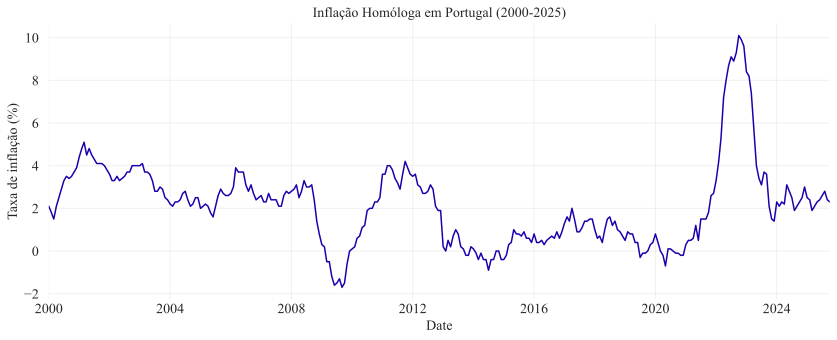

In [8]:
plt.figure(figsize=(14, 5), dpi=500)
sns.lineplot(data=df, x='Date', y=target, color='#1800ad')

ax = plt.gca()

ax.set_xlim(df['Date'].min(), df['Date'].max())

ax.yaxis.grid(True, color='#d9d9d9', alpha=0.4)
ax.xaxis.grid(True, color='#d9d9d9', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=10)

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title(
    "Inflação Homóloga em Portugal (2000-2025)",
    loc='center',
    fontname='Times New Roman',
    fontsize=14
)
plt.ylabel("Taxa de inflação (%)", fontname='Times New Roman', fontsize=14)
plt.xlabel("Date", fontname='Times New Roman', fontsize=14)

plt.xticks(fontname='Times New Roman', fontsize=14)
plt.yticks(fontname='Times New Roman', fontsize=14)

plt.show()

Para os dados até ao momento

In [9]:
target_df = pd.read_csv(
    "dados/target_04_2026.csv",
    sep=";",
    encoding="latin1"
)

target_df.columns = target_df.columns.str.replace("# ", "", regex=False).str.strip()

target_df = target_df[["Período de referência", "Valor"]].copy()

target_df["Date"] = (
    pd.to_datetime(target_df["Período de referência"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

target_df = target_df.rename(columns={"Valor": "inflation_target"})
target_df = target_df[["Date", "inflation_target"]]
target_df = target_df[target_df["Date"] >= "2000-01-01"].reset_index(drop=True)

target_df.head(3)

,Date,inflation_target
0,2000-01-01,2.1
1,2000-02-01,1.8
2,2000-03-01,1.5


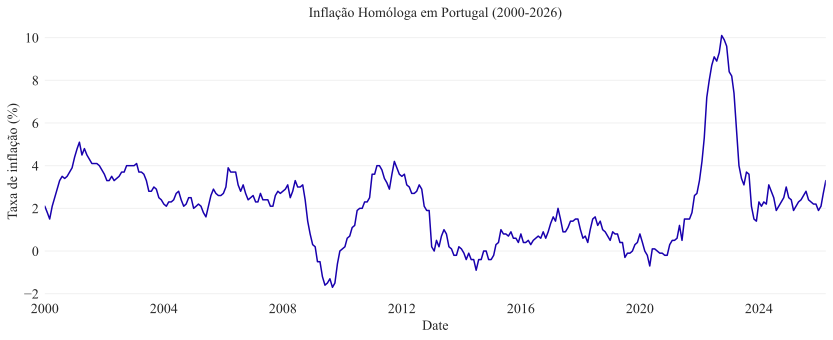

In [10]:

plt.figure(figsize=(14, 5), dpi=500)
sns.lineplot(data=target_df, x='Date', y='inflation_target', color='#1800ad')

ax = plt.gca()

ax.set_xlim(target_df['Date'].min(), target_df['Date'].max())

ax.yaxis.grid(True, color='#d9d9d9', alpha=0.4)
ax.xaxis.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=6)

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title(
    "Inflação Homóloga em Portugal (2000-2026)",
    loc='center',
    fontname='Times New Roman',
    fontsize=14
)
plt.ylabel("Taxa de inflação (%)", fontname='Times New Roman', fontsize=14)
plt.xlabel("Date", fontname='Times New Roman', fontsize=14)

plt.xticks(fontname='Times New Roman', fontsize=14)
plt.yticks(fontname='Times New Roman', fontsize=14)

plt.show()

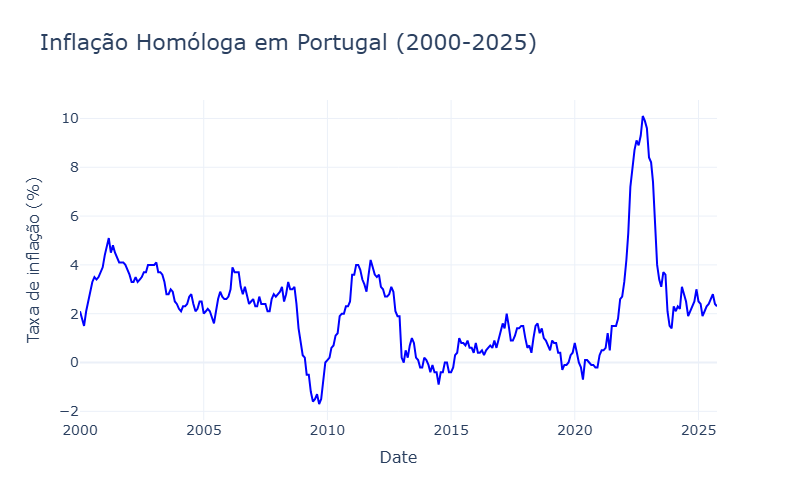

In [11]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.Date, y=df[target], mode='lines', name='Inflation',
                        line=dict(color='blue', width=2)))

fig.update_layout(title='Inflação Homóloga em Portugal (2000-2025)',
                  xaxis_title='Date', yaxis_title='Taxa de inflação (%)',
                  # 🔹 Fonte global (base)
                  font=dict(
                      size=ticket_size
                  ),
                    
                  # 🔹 Título principal
                  title_font=dict(
                      size=title_size
                  ),

                  # 🔹 Eixos
                  xaxis=dict(
                      title_font=dict(size=label_size),
                      tickfont=dict(size=ticket_size),
                  ),

                  yaxis=dict(
                      title_font=dict(size=label_size),
                      tickfont=dict(size=ticket_size)
                  ),
                  template='plotly_white', height=500)
fig.show()

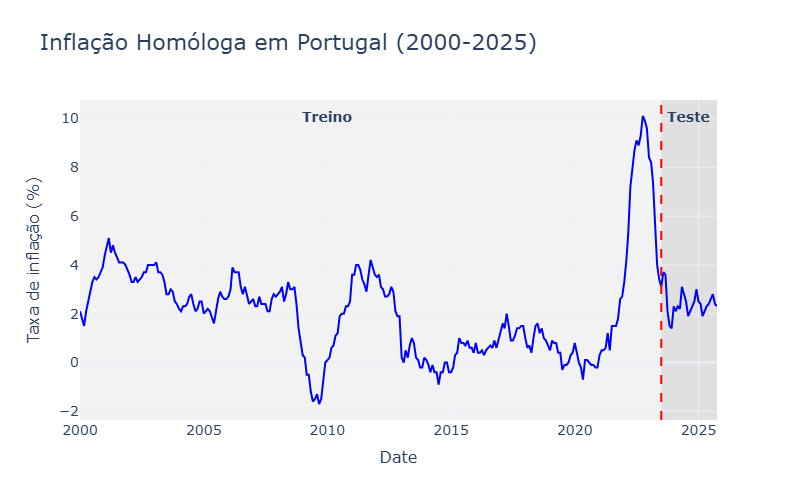

In [12]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.Date, y=df[target], mode='lines', name='Inflation',
                        line=dict(color='blue', width=2)))

fig.add_vline(
    x="2023-07-01",
    line_width=2,
    line_dash="dash",
    line_color="red"
    # annotation_text="Julho 2023",
    # annotation_position="top right"
)

split_date = "2023-07-01"

fig.add_vrect(
    x0=df["Date"].min(),
    x1=split_date,
    fillcolor="rgba(0, 0, 0, 0.05)",
    # opacity=0.1,
    layer="below",
    line_width=0,
)

fig.add_vrect(
    x0=split_date,
    x1=df["Date"].max(),
    fillcolor="rgba(0, 0, 0, 0.12)",
    # opacity=0.1,
    layer="below",
    line_width=0,
)

fig.add_annotation(x="2010-01-01", y=max(df[target]),
                   text="Treino",
                   showarrow=False,
                   font=dict(size=14, weight='bold'))

fig.add_annotation(x="2024-08-01", y=max(df[target]),
                   text="Teste",
                   showarrow=False,
                   font=dict(size=14, weight='bold'))

fig.update_layout(title='Inflação Homóloga em Portugal (2000-2025)',
                  xaxis_title='Date', yaxis_title='Taxa de inflação (%)',
                  # 🔹 Fonte global (base)
                  font=dict(
                      size=ticket_size
                  ),
                    
                  # 🔹 Título principal
                  title_font=dict(
                      size=title_size
                  ),

                  # 🔹 Eixos
                  xaxis=dict(
                      title_font=dict(size=label_size),
                      tickfont=dict(size=ticket_size),
                  ),

                  yaxis=dict(
                      title_font=dict(size=label_size),
                      tickfont=dict(size=ticket_size)
                  ),
                  template='plotly_white', height=500)
fig.show()

---
A série da inflação não apresenta nenhuma tendência nem evidencia sazonalidade, verifica-se apenas a existência de ciclos largos que podem ter sido causados por diferentes fatores económico-políticos.

---

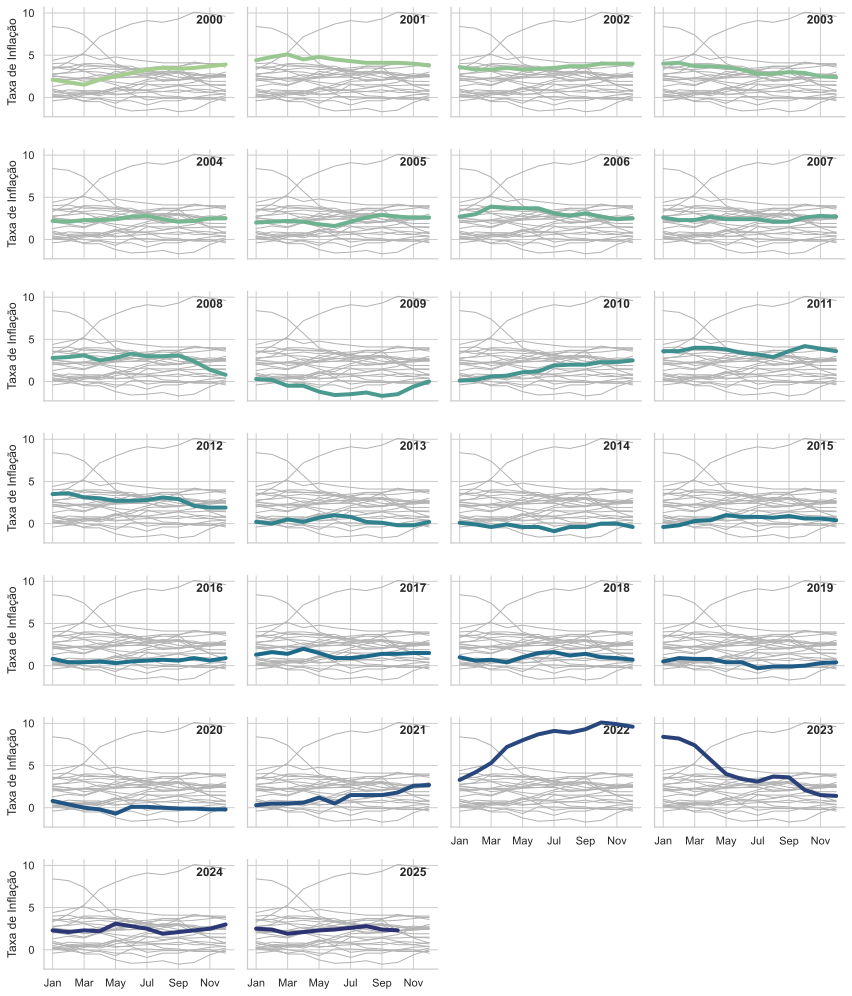

In [13]:
# sns.set_theme(style="dark")

# Plot each year's time series in its own facet
g = sns.relplot(
    data=df,
    x="month", y=target, col="year", hue="year",
    kind="line", palette="crest", linewidth=4, zorder=5,
    col_wrap=4, height=2, aspect=1.5, legend=False,
    
)

# Iterate over each subplot to customize further
for year, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.8, .85, year, transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=df, x="month", y=target, units="year",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("")
g.set_axis_labels("", "Taxa de Inflação")
g.tight_layout()
plt.show()

In [14]:
import plotly.graph_objects as go

years = sorted(df["year"].unique())

fig = go.Figure()

# 🔹 Criar todas as linhas (uma por ano)
for y in years:
    df_y = df[df["year"] == y]
    
    fig.add_trace(go.Scatter(
        x=df_y["month"],
        y=df_y[target],
        mode="lines",
        line=dict(color="lightgray", width=1),
        opacity=0.7,
        showlegend=False,
        name=str(y)
    ))

# 🔹 Função para atualizar cores + destaque
def get_trace_styles(highlight_year):
    styles = []
    for y in years:
        if y == highlight_year:
            styles.append(dict(line=dict(color="#1f3b73", width=4), opacity=1))
        else:
            styles.append(dict(line=dict(color="lightgray", width=1), opacity=0.3))
    return styles

# 🔹 Criar botões do dropdown
buttons = []

for highlight_year in years:
    
    df_high = df[df["year"] == highlight_year]
    
    x_last = df_high["month"].iloc[-1]
    y_last = df_high[target].iloc[-1]
    
    styles = get_trace_styles(highlight_year)
    
    buttons.append(
        dict(
            label=str(highlight_year),
            method="update",
            args=[
                # Atualizar estilo das linhas
                {"line": [s["line"] for s in styles],
                 "opacity": [s["opacity"] for s in styles]},
                
                # Atualizar annotation (ticket)
                {"annotations": [
                    dict(
                        x=x_last,
                        y=y_last,
                        text=f"<b>{highlight_year}</b>",
                        showarrow=False,
                        yshift=20,
                        font=dict(
                            color="#1f3b73",
                            size=12,
                            family='arial'
                        )
                    )
                ]}
            ]
        )
    )

# 🔹 Layout com dropdown
fig.update_layout(
    title='Inflação Homóloga por Ano',
    xaxis_title='Mês',
    yaxis_title='Taxa de inflação (%)',
    template="plotly_white",
    showlegend=False,
    height=500,
    
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0.01,
            y=1.15,
            showactive=True
        )
    ]
)

fig.show()

In [15]:
# Escolher ano a destacar
highlight_year = 2022

# Criar figura
fig = go.Figure()

# 🔹 Linhas cinza (todos os anos menos o destaque)
for y in df["year"].unique():
    if y != highlight_year:
        df_y = df[df["year"] == y]
        fig.add_trace(go.Scatter(
            x=df_y["month"],
            y=df_y[target],
            mode="lines",
            line=dict(color="lightgray", width=1),
            opacity=0.7,
            showlegend=False
        ))

# 🔹 Linha destacada
df_high = df[df["year"] == highlight_year]

fig.add_trace(go.Scatter(
    x=df_high["month"],
    y=df_high[target],
    mode="lines",
    line=dict(color="#1f3b73", width=4),  # azul escuro
    name=str(highlight_year)
))

# Último ponto da série destacada
x_last = df_high["month"].iloc[-1]
y_last = df_high[target].iloc[-1]

# 🔹 Label tipo "ticket"
fig.add_annotation(
    x=x_last,
    y=y_last,
    text=str(highlight_year),
    showarrow=False,
    
    # posição ligeiramente acima
    yshift=15,
    
    # estilo do "ticket"
    font=dict(
        color="#1f3b73",
        size=12,
        weight='bold',
        family='arial'
    ),
    
    # arredondamento visual
    align="center"
)

# 🔹 Layout
fig.update_layout(
    title='Inflação Homóloga por Ano',
    template="plotly_white",
    
    # 🔹 Fonte global (base)
    font=dict(
        # family='Arial',
        size=12,
    ),

    # 🔹 Título principal
    title_font=dict(
        size=title_size
    ),

    # 🔹 Eixos
    xaxis=dict(
        title='Mês',
        title_font=dict(size=label_size),
        tickfont=dict(size=ticket_size)
    ),
    
    yaxis=dict(
        title='Taxa de inflação (%)',
        title_font=dict(size=label_size),
        tickfont=dict(size=ticket_size)
    ),

    showlegend=False,
    height=500
)

fig.show()

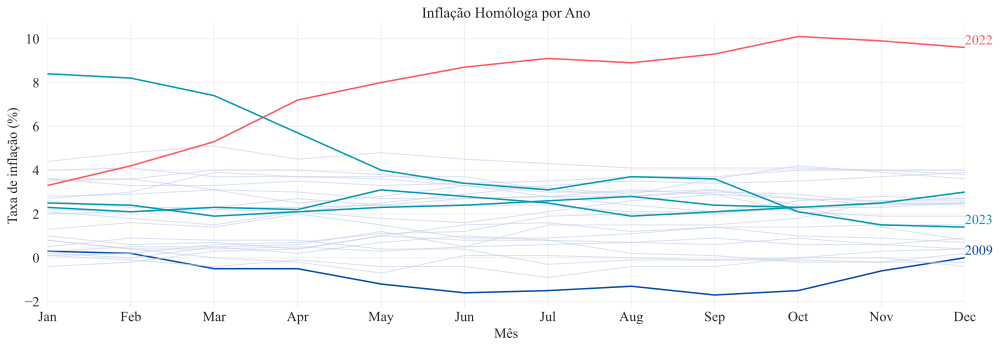

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

highlight_years = [2022, 2009, 2023, 2024, 2025]
label_years = [2022, 2009, 2023]

colors = {
    2022: "#ff5757",
    2009: "#004aad",
    2023: "#0097b2",
    2024: "#0097b2",
    2025: "#0097b2"
}

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df_plot = df.copy()
df_plot["month_num"] = df_plot["month"].map({
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
})

plt.figure(figsize=(14, 5), dpi=600)
ax = plt.gca()

for y in sorted(df_plot["year"].unique()):
    df_y = df_plot[df_plot["year"] == y].sort_values("month_num")

    sns.lineplot(
        data=df_y,
        x="month_num",
        y=target,
        estimator=None,
        color=colors[y] if y in highlight_years else "#cad4ec",
        linewidth=1.5 if y in highlight_years else 1,
        alpha=1 if y in highlight_years else 0.7,
        legend=False,
        ax=ax
    )

for y in label_years:
    df_y = df_plot[df_plot["year"] == y].sort_values("month_num")
    ax.text(
        df_y["month_num"].iloc[-1],
        df_y[target].iloc[-1],
        str(y),
        color=colors[y],
        fontsize=14,
        fontname="Times New Roman",
        ha="left",
        va="bottom"
    )

ax.set_xlim(1, 12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontname="Times New Roman", fontsize=14)

ax.grid(True, color="#d9d9d9", alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, pad=8)

ax.set_title("Inflação Homóloga por Ano", fontname="Times New Roman", fontsize=15)
ax.set_xlabel("Mês", fontname="Times New Roman", fontsize=14)
ax.set_ylabel("Taxa de inflação (%)", fontname="Times New Roman", fontsize=14, labelpad=0)
ax.yaxis.set_label_coords(-0.03, 0.5)

for label in ax.get_yticklabels():
    label.set_fontname("Times New Roman")
    label.set_fontsize(14)

plt.tight_layout()
plt.savefig("Imagens/inflacao_homologa_por_ano.svg", bbox_inches="tight")
plt.show()

---
**2009:** A falência do **Lehman Brothers**, o quarto maior banco de investimento dos Estados Unidos, foi há dez anos e simboliza a maior crise financeira desde o ‘crash’ de 1930. Na primeira hora do dia **15 de setembro de 2008**, um tribunal federal norte-americano recebeu a formalização da falência do gigante da indústria financeira, uma decisão que mudaria a história económico-financeira mundial. https://24noticias.sapo.pt/economia/artigos/de-wall-street-a-lisboa-como-a-crise-de-2008-atravessou-o-atlantico

Aquilo que era uma crise financeira transformou-se numa crise económica e, **a partir de 2010**, a crise das dívida soberanas levou mesmo a **resgates à Grécia, _Portugal_, Irlanda e Chipre**, enquanto Espanha recebeu apoios para o setor financeiro, num total de quase 500 mil milhões de euros.

**2022:** Em Portugal, 2022 está a ser marcado pelas consequências da **Invasão russa da Ucrânia**, com a galopante inflação levando ao **aumento do custo de vida**; pelas **medidas de austeridade** impostas pelo Governo para diminuir a dívida e aumentar a receita. Austeridade essa que está a afetar principalmente os pensionistas e reformados.

As medidas de austeridade referem-se a um **conjunto de políticas fiscais** implementadas por governos com o **objetivo de controlar a dívida pública e equilibrar as contas do Estado**. 

O principal **objetivo das medidas de austeridade é reduzir o déficit fiscal**, aproximando as receitas do governo das despesas. Isso pode ajudar a estabilizar a economia e evitar crises financeiras, além de demonstrar disciplina fiscal para credores e agências de classificação de crédito, facilitando o acesso a empréstimos futuros.

---

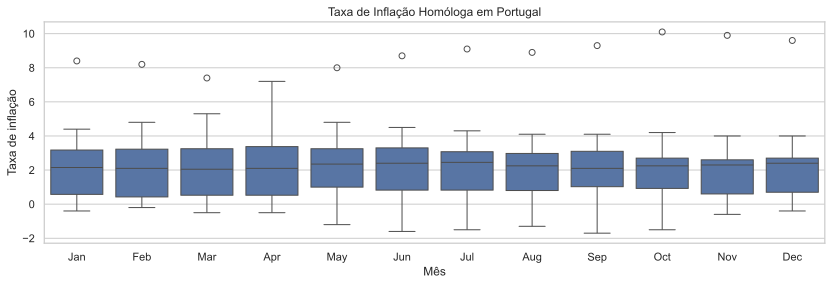

In [17]:
plt.figure(figsize=(14, 4), dpi=500)
sns.boxplot(df, y=target, x='month')

plt.title("Taxa de Inflação Homóloga em Portugal")
plt.ylabel("Taxa de inflação")
plt.xlabel("Mês")
plt.show()

In [18]:
df.month.unique()

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'], dtype=object)

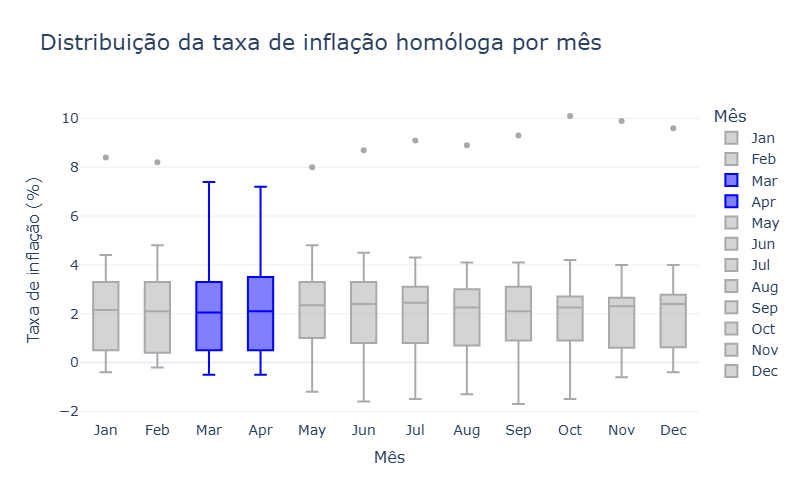

In [19]:
easter = ['Mar', 'Apr']
colors = ['blue' if month in easter else 'darkgrey' for month in df.month.unique()]
fig_box = px.box(df, x='month', y=target, title='Distribuição da taxa de inflação homóloga por mês',
                color='month', color_discrete_sequence=colors) # px.colors.qualitative.Set3

fig_box.update_layout(height=500, template='plotly_white',
                     xaxis_title='Mês', yaxis_title='Taxa de inflação (%)',
                      
                     font=dict(
                         size=ticket_size
                     ),
                        
                     # 🔹 Título principal
                     title_font=dict(
                         size=title_size
                     ),
    
                     # 🔹 Eixos
                     xaxis=dict(
                         title_font=dict(size=label_size),
                         tickfont=dict(size=ticket_size),
                    ),
    
                   yaxis=dict(
                          title_font=dict(size=label_size),
                          tickfont=dict(size=ticket_size)
                   ),
                   legend_title="Mês")

# fig_box.add_hline(
#     y=3.6,
#     line_dash="dash",
#     line_color="red"
# )

fig_box.show()

# How do other series affect the inflation in Portugal?

In [20]:
fred_var = [col for col in df.columns if 'fred-md' in col]
ea_md = [col for col in df.columns if 'ea-md' in col]

## Inflation rate vs Economic Policy Uncertainty for Portugal

---
*This dataset includes contributions from two news agencies, seven national newspapers, five business newspapers, two regional newspapers, two online newspapers, four magazines, and one radio station. The search is geographically limited to Portugal*.

*The search criteria focused on articles that included at least one keyword from each of the designated categories: “Economy” (E), “Policy” (P), and “Uncertainty” (U). Specifically, the search parameters were as follows: ((incerto/a OR incerteza OR instabilidade OR instável OR indefinição OR indecisão OR dúvida OR risco/s) AND (económico/a OR economia) AND (Parlamento OR Palácio de São Bento OR governo OR ministério das finanças OR Comissão Europeia OR défice OR orçamento OR ((o OR de OR do OR um OR por OR este OR esse OR aquele) with imposto/s) OR legislação/ões OR norma/s OR normativa/o OR regulação/ões OR regulamento/s OR lei/s)).*

O EPU (Economic Policy Uncertainty Index) mede o grau de incerteza económica associada a decisões de política pública. Ele é construído a partir da frequência de notícias que mencionam simultaneamente três tipos de termos:

- Economia
- Política
- Incerteza

Quanto mais frequentemente estes temas aparecem juntos na imprensa, maior é o nível de incerteza captado pelo índice.

**Valor alto do índice**

Indica que:

- Há muita incerteza sobre decisões políticas (ex.: orçamentos, eleições, crises governamentais).
- Empresas tendem a adiar investimentos.
- Consumidores tornam-se mais cautelosos.
- Mercados financeiros reagem com quedas nas ações e alargamento dos spreads de crédito.

**Valor baixo do índice**

Sugere:

- Ambiente económico mais previsível.
- Decisões políticas estáveis.
- Empresas e consumidores mais confiantes.

O artigo mostra que, em Portugal, choques de incerteza têm efeitos **rápidos nos mercados financeiros e mais lentos na economia real**.

---

In [21]:
print("-" * 30)
print("Describing EPU")
print("-" * 30)
print(df['epu_pt_epu'].describe())
print("-" * 30)
print("EPU information")
print("-" * 30)
df['epu_pt_epu'].info()

------------------------------
Describing EPU
------------------------------
count    310.000000
mean      98.876209
std       28.644891
min       28.950320
25%       79.372278
50%       95.348712
75%      116.413888
max      215.843320
Name: epu_pt_epu, dtype: float64
------------------------------
EPU information
------------------------------
<class 'pandas.core.series.Series'>
RangeIndex: 310 entries, 0 to 309
Series name: epu_pt_epu
Non-Null Count  Dtype  
--------------  -----  
310 non-null    float64
dtypes: float64(1)
memory usage: 2.6 KB


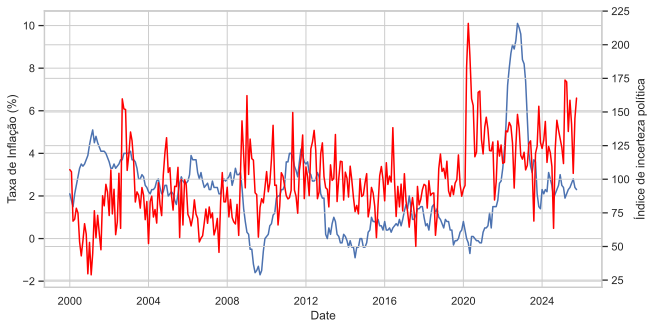

In [22]:
# Criar figura e eixo principal
fig, ax1 = plt.subplots(figsize=(10,5), dpi=500)

# Primeira linha
sns.lineplot(data=df, x="Date", y=target, ax=ax1)
ax1.set_ylabel("Taxa de Inflação (%)")

# Segundo eixo Y
ax2 = ax1.twinx()

# Segunda linha
sns.lineplot(data=df, x="Date", y="epu_pt_epu", ax=ax2, color="red")
ax2.set_ylabel("Índice de incerteza política")

plt.show()

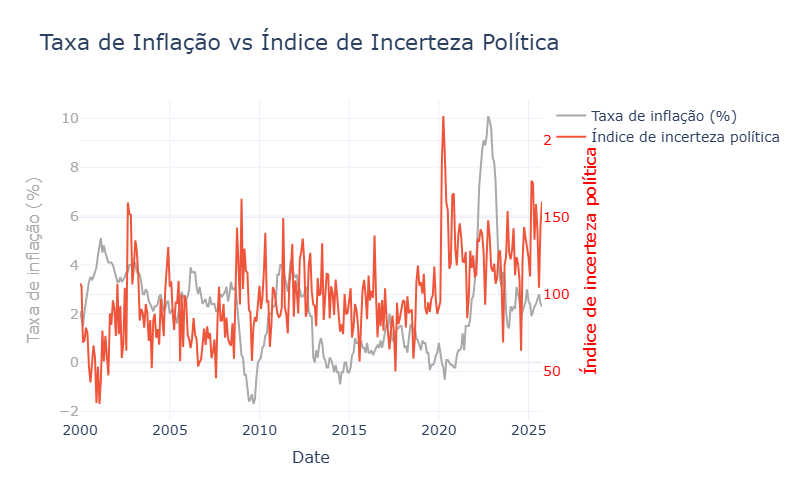

In [23]:
fig = go.Figure()

# Linha 1 (eixo Y esquerdo)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df[target],
        mode="lines",
        name="Taxa de inflação (%)",
        yaxis="y",
        line=dict(color='darkgrey')
    )
)

# Linha 2 (eixo Y direito)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["epu_pt_epu"],
        mode="lines",
        name="Índice de incerteza política",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Taxa de Inflação vs Índice de Incerteza Política",
    
    yaxis2=dict(
        title="Índice de incerteza política",
        overlaying="y",   # partilha o mesmo eixo X
        side="right",      # eixo aparece à direita
        color="red"
    ),

    font=dict(
         size=ticket_size
     ),
        
     # 🔹 Título principal
     title_font=dict(
         size=title_size
     ),

     # 🔹 Eixos
     xaxis=dict(
         title="Date",
         title_font=dict(size=label_size),
         tickfont=dict(size=ticket_size),
    ),

   yaxis=dict(
          title="Taxa de inflação (%)",
          color="darkgrey",
          title_font=dict(size=label_size),
          tickfont=dict(size=ticket_size)
   ),

    template='plotly_white', height=500
)

fig.show()

In [24]:
# high-quality figures (output)
%config InlineBackend.figure_format = 'svg'

## Inflation vs Unemployment (15+ years)

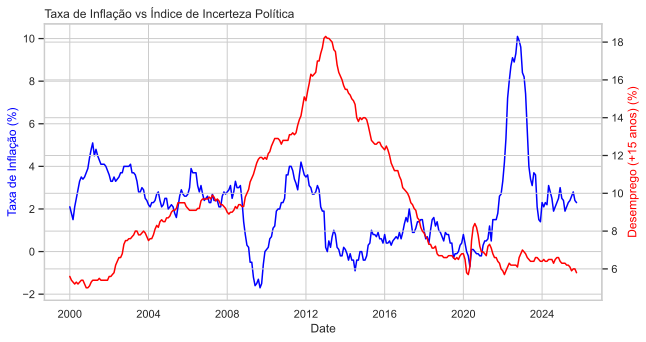

In [25]:
# Criar figura e eixo principal
fig, ax1 = plt.subplots(figsize=(10,5), dpi=500)

# Primeira linha
sns.lineplot(data=df, x="Date", y=target, ax=ax1, color="blue")
ax1.set_ylabel("Taxa de Inflação (%)", fontdict=dict(color="blue"))

# Segundo eixo Y
ax2 = ax1.twinx()

# Segunda linha
sns.lineplot(data=df, x="Date", y="unemployment_up_15_unemployment", ax=ax2, color="red")
ax2.set_ylabel("Desemprego (+15 anos) (%)", fontdict=dict(color="red"))

plt.title("Taxa de Inflação vs Índice de Incerteza Política", loc='left')
plt.show()

In [26]:
fig = go.Figure()

# Linha 1 (eixo Y esquerdo)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df[target],
        mode="lines",
        name="Taxa de inflação (%)",
        yaxis="y",
        line=dict(color='darkgrey')
    )
)

# Linha 2 (eixo Y direito)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["unemployment_up_15_unemployment"],
        mode="lines",
        name="Desemprego (+15 anos) (%)",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Taxa de Inflação vs Taxa de Desemprego (+15 anos)",
    
    xaxis=dict(title="Date"),
    
    yaxis=dict(
        title="Taxa de inflação (%)",
        color="darkgrey"
    ),
    
    yaxis2=dict(
        title="Desemprego (+15 anos) (%)",
        color="red",
        overlaying="y",   # partilha o mesmo eixo X
        side="right"      # eixo aparece à direita
    ),

    template='plotly_white', height=500
)

fig.show()

## Inflation vs Product Price Index (%)

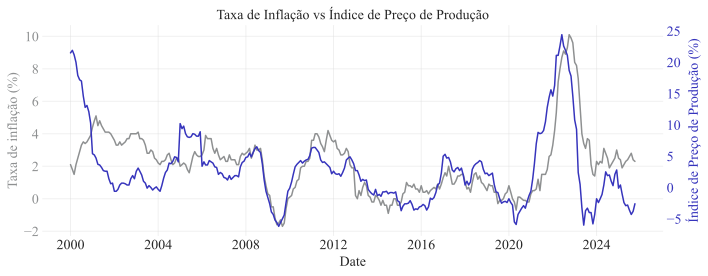

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax1 = plt.subplots(figsize=(10, 4), dpi=600)

# Eixo esquerdo
sns.lineplot(
    data=df,
    x="Date",
    y=target,
    ax=ax1,
    color="#8E9091",
    linewidth=1.5
)

ax1.set_ylabel("Taxa de inflação (%)", fontname="Times New Roman", fontsize=14, color="#8E9091")
ax1.set_xlabel("Date", fontname="Times New Roman", fontsize=14)
ax1.tick_params(axis="y", labelcolor="#8E9091", length=0)
ax1.tick_params(axis="x", length=0)

# Eixo direito
ax2 = ax1.twinx()

sns.lineplot(
    data=df,
    x="Date",
    y="PPIPT_ppi",
    ax=ax2,
    color="#3634bc",  # azul
    linewidth=1.5
)

ax2.set_ylabel("Índice de Preço de Produção (%)", fontname="Times New Roman", fontsize=14, color="#3634bc")
ax2.tick_params(axis="y", labelcolor="#3634bc", length=0)

# Título
ax1.set_title(
    "Taxa de Inflação vs Índice de Preço de Produção",
    fontname="Times New Roman",
    fontsize=14
)

# Fonte dos ticks
for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    label.set_fontname("Times New Roman")
    label.set_fontsize(14)

# Estilo visual
ax1.grid(True, color="#d9d9d9", alpha=0.4)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_visible(False)
ax1.spines["bottom"].set_visible(False)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

## Inflation vs FRED-MD variables

In [28]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_fred-md', '') for col in fred_var[0:6]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in fred_var[0:6]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_fred-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da FRED-MD",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [29]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_fred-md', '') for col in fred_var[6:12]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in fred_var[6:12]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_fred-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da FRED-MD",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [30]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=[col.replace('_fred-md', '') for col in fred_var[12:]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in fred_var[12:]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_fred-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 2:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da FRED-MD",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [31]:
fig = go.Figure()

# Linha 1 (eixo Y esquerdo)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df[target],
        mode="lines",
        name="Taxa de inflação (%)",
        yaxis="y",
        line=dict(color='darkgrey')
    )
)

# Linha 2 (eixo Y direito)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["OILPRICEx_fred-md_Eur"],
        mode="lines",
        name="Preço do petróleo (euros)",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Taxa de Inflação vs Preço do Petróleo (euros)",
    
    yaxis2=dict(
        title="Preço do petróleo (euros)",
        color="red",
        overlaying="y",   # partilha o mesmo eixo X
        side="right"      # eixo aparece à direita
    ),


    font=dict(
         size=ticket_size
     ),
        
     # 🔹 Título principal
     title_font=dict(
         size=title_size
     ),

     # 🔹 Eixos
     xaxis=dict(
         title="Date",
         title_font=dict(size=label_size),
         tickfont=dict(size=ticket_size),
    ),

   yaxis=dict(
          title="Taxa de inflação (%)",
          color="darkgrey",
          title_font=dict(size=label_size),
          tickfont=dict(size=ticket_size)
   ),

    template='plotly_white', height=500
)

fig.show()

In [32]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df[target],
        mode="lines",
        name="Taxa de inflação (%)",
        yaxis="y",
        line=dict(color="#8E9091", width=1.5),
    )
)

fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["OILPRICEx_fred-md_Eur"],
        mode="lines",
        name="Preço do petróleo (euros)",
        yaxis="y2",
        line=dict(color="#3634bc", width=1.5),
    )
)

fig.update_layout(
    title=dict(
        text="Taxa de Inflação vs Preço do Petróleo (euros)",
        x=0.5,
        xanchor="center",
        font=dict(family="Times New Roman", size=14),
    ),
    font=dict(
        family="Times New Roman",
        size=14,
        color="black",
    ),
    xaxis=dict(
        title="Date",
        title_font=dict(size=14),
        tickfont=dict(size=14),
        showgrid=True,
        gridcolor="#d9d9d9",
        gridwidth=1,
        zeroline=False,
        showline=False,
        ticks="",
    ),
    yaxis=dict(
        title="Taxa de inflação (%)",
        title_font=dict(size=14, color="#8E9091"),
        tickfont=dict(size=14, color="#8E9091"),
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks="",
    ),
    yaxis2=dict(
        title="Preço do petróleo (euros)",
        title_font=dict(size=14, color="#3634bc"),
        tickfont=dict(size=14, color="#3634bc"),
        overlaying="y",
        side="right",
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks="",
    ),
    template="plotly_white",
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    margin=dict(l=40, r=40, t=60, b=40),
)

fig.show()

---
**OILPRICEx_Eur:** Apesar de ser com algum defasamento, verifica-se que a variação do preço do petróleo tem uma tendência semelhante a variação da inflação em Portugal. Verifica-se também que nem sempre (ou quase nunca) a resposta da inflação surge numa mesma dismensão ao aumento ou redução do preço do petróleo.

---

## Inflation vs Euro Area - Monthly Data variables

In [33]:
ea_md_var = [col for col in df.columns if 'ea-md' in col]
len(ea_md_var)

34

In [34]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-md', '') for col in ea_md_var[0:6]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_md_var[0:6]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_ea-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area - Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [35]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-md', '') for col in ea_md_var[6:12]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_md_var[6:12]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_ea-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area - Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [36]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-md', '') for col in ea_md_var[12:18]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_md_var[12:18]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_ea-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area - Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [37]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-md', '') for col in ea_md_var[18:24]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_md_var[18:24]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_ea-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area - Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [38]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-md', '') for col in ea_md_var[24:30]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_md_var[24:30]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_ea-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area - Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [39]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=[col.replace('_ea-md', '') for col in ea_md_var[30:]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_md_var[30:]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode="lines",
            name=column.replace("_ea-md", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 2:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area - Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

## Inflation vs Euro Area Quartely Data

In [40]:
ea_qd_var = [col for col in df.columns if 'ea-qd' in col]
len(ea_qd_var)

65

In [41]:
mode_qd = 'markers'

In [42]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[0:6]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[0:6]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [43]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[6:12]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[6:12]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [44]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[12:18]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[12:18]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [45]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[18:24]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[18:24]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

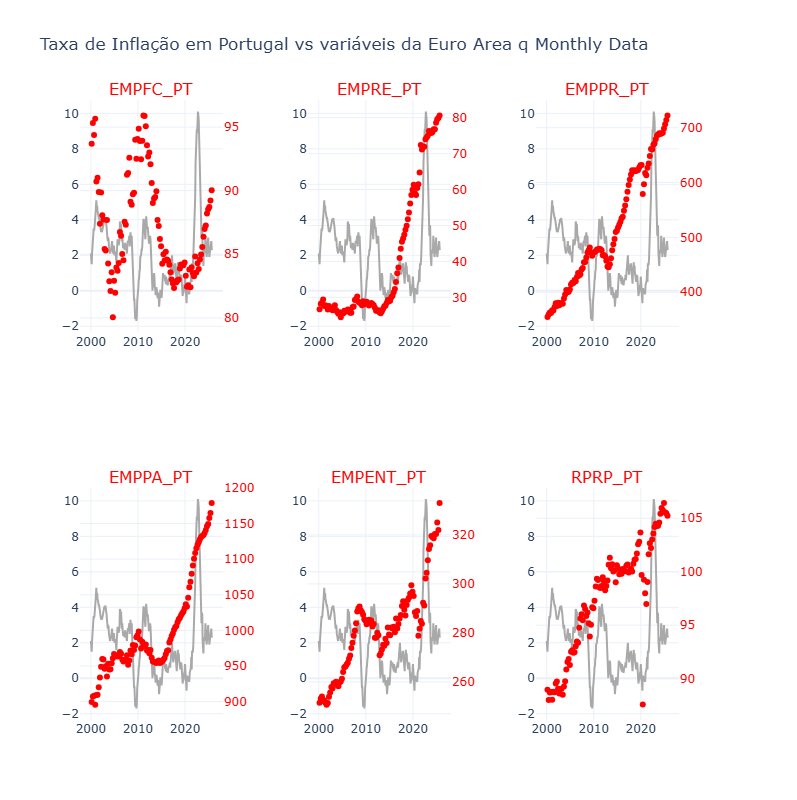

In [46]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[24:30]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[24:30]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

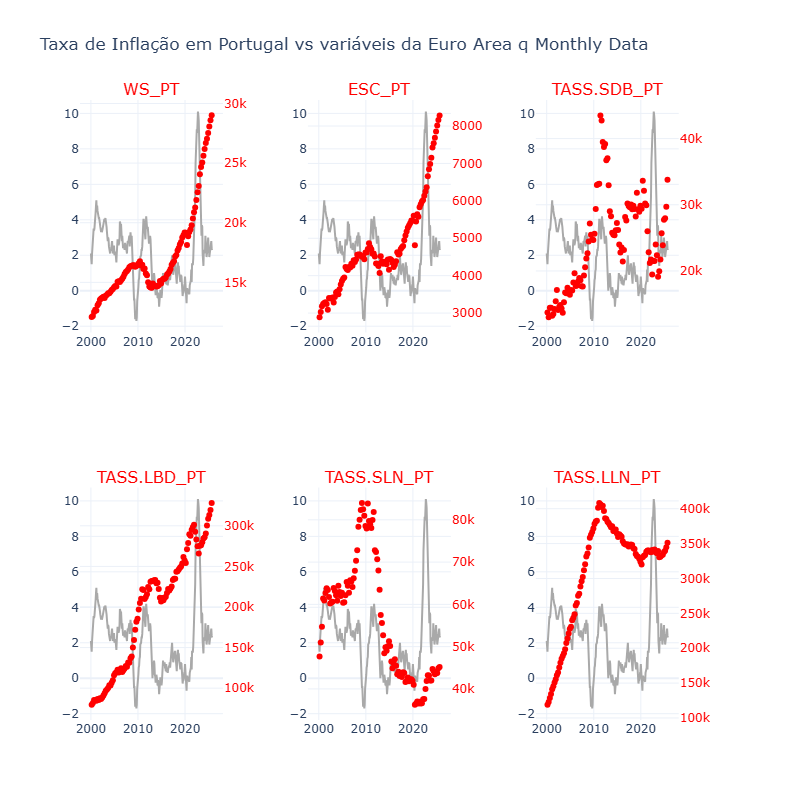

In [47]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[30:36]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[30:36]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

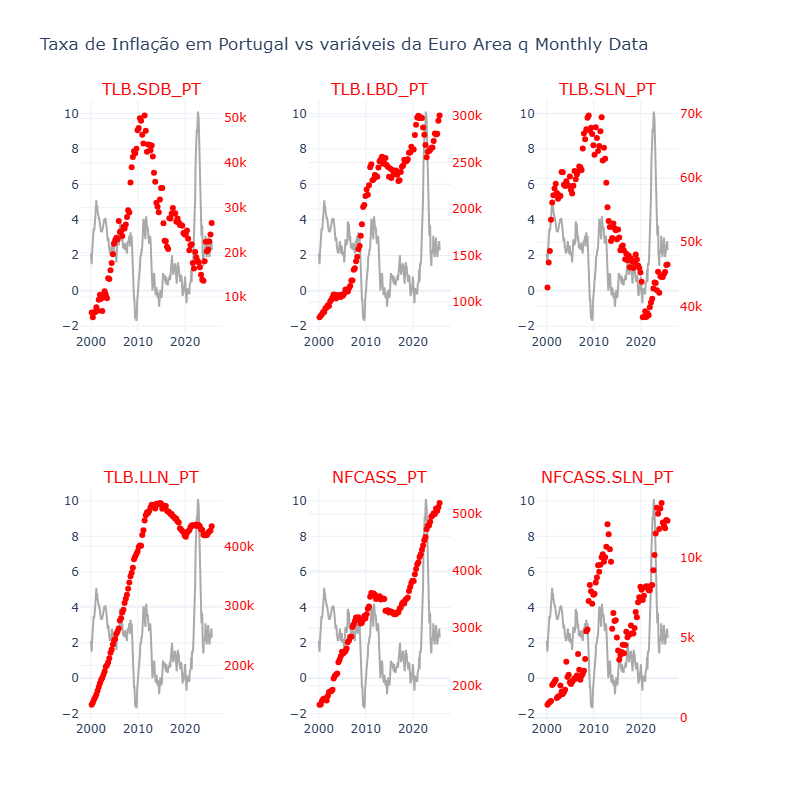

In [48]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[36:42]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[36:42]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

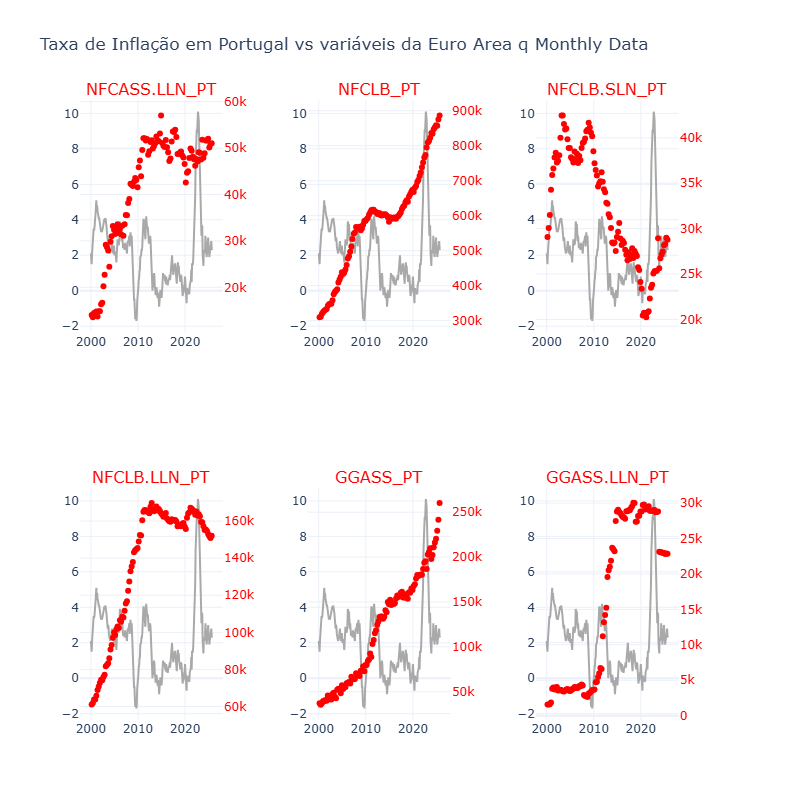

In [49]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[42:48]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[42:48]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

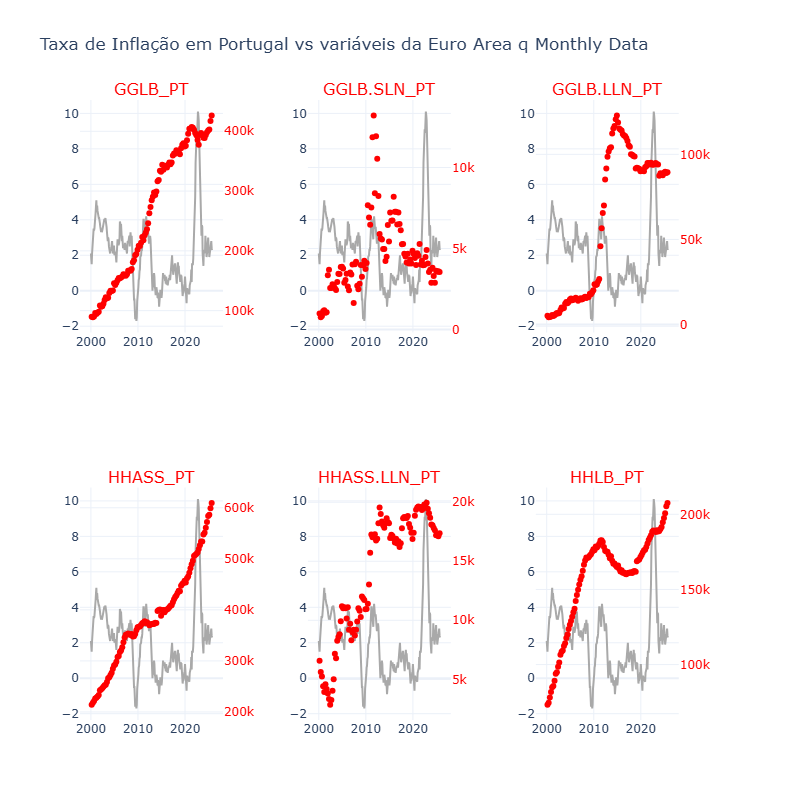

In [50]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[48:54]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[48:54]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

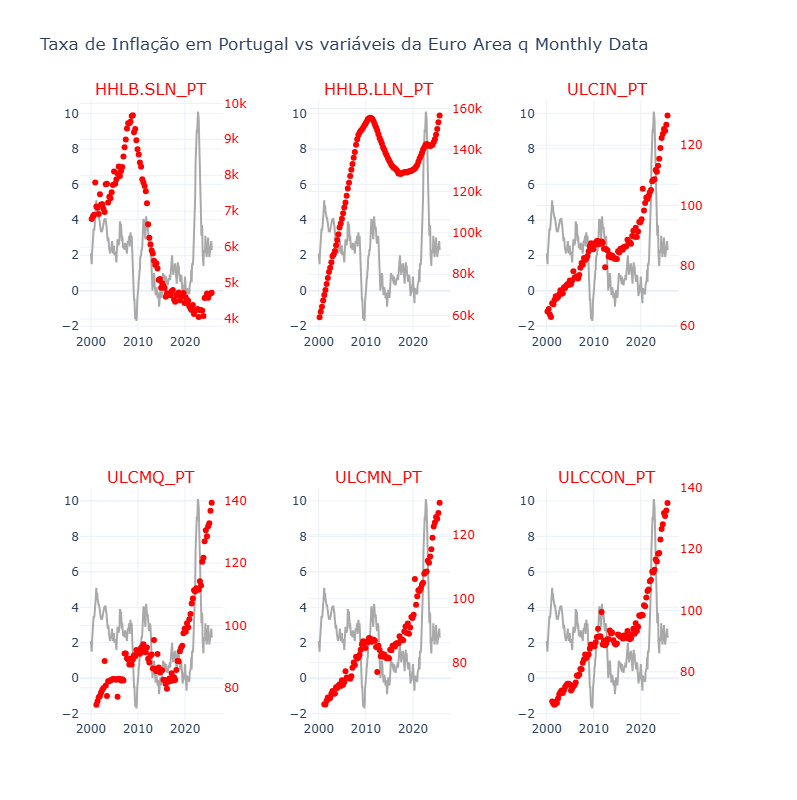

In [51]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[54:60]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[54:60]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [52]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=3,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[54:60]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[54:60]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 3:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [53]:
# Comprehensive dashboard with subplots
fig_dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=[col.replace('_ea-qd', '') for col in ea_qd_var[60:64]],
    specs=[[{"secondary_y": True}, {"secondary_y": True}],
           [{"secondary_y": True}, {"secondary_y": True}]]
)
row = 1
col = 1

for column in ea_qd_var[60:64]:
    #
    fig_dashboard.add_trace(
        go.Scatter(
            x=df.Date, 
            y=df[target], 
            mode='lines', 
            name='Taxa de Inflação',
            line=dict(color='darkgrey')
        ), 
        row=row, col=col,
        secondary_y=False
    )
    
    # Linha 2 (eixo Y direito)
    fig_dashboard.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[column],
            mode=mode_qd,
            name=column.replace("_ea-qd", ""),
            line=dict(color="red")
        ),
        row=row, col=col,
        secondary_y=True
    )

    fig_dashboard.update_yaxes(
        title_font_color="red",
        tickfont_color="red",
        row=row, col=col,
        secondary_y=True
    )

    col += 1
    if col > 2:
        row += 1
        col = 1

fig_dashboard.update_layout(height=800, title_text="Taxa de Inflação em Portugal vs variáveis da Euro Area q Monthly Data",
                            showlegend=False,
                           template='plotly_white')
fig_dashboard.update_annotations(
    font=dict(
        color="red"
    )
)

fig_dashboard.show()

In [54]:
fig = go.Figure()

# Linha 1 (eixo Y esquerdo)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df[target],
        mode="lines",
        name="Taxa de inflação (%)",
        yaxis="y",
        line=dict(color='darkgrey')
    )
)

# Linha 2 (eixo Y direito)
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df[ea_qd_var[-1]],
        mode=mode_qd,
        name=ea_qd_var[-1].replace('_ea-qd', ''),
        yaxis="y2"
    )
)

fig.update_layout(
    title=f"Taxa de Inflação vs {ea_qd_var[-1].replace('_ea-qd', '')}",
    
    xaxis=dict(title="Date"),
    
    yaxis=dict(
        title="Taxa de inflação (%)",
        color="darkgrey"
    ),
    
    yaxis2=dict(
        title=ea_qd_var[-1].replace('_ea-qd', ''),
        color="red",
        overlaying="y",   # partilha o mesmo eixo X
        side="right"      # eixo aparece à direita
    ),

    template='plotly_white', height=500
)

fig.show()

#### Lag 0

In [55]:
df[[target, 'OILPRICEx_fred-md_Eur']].corr()

,inflation_target,OILPRICEx_fred-md_Eur
inflation_target,1.000000,0.236941
OILPRICEx_fred-md_Eur,0.236941,1.000000


#### Lag 2

In [56]:
df2 = df.copy()
df2['oil_lag4'] = df2['OILPRICEx_fred-md_Eur'].shift(2)
df2[[target, 'oil_lag4']].dropna(axis=0).corr()

,inflation_target,oil_lag4
inflation_target,1.000000,0.242471
oil_lag4,0.242471,1.000000


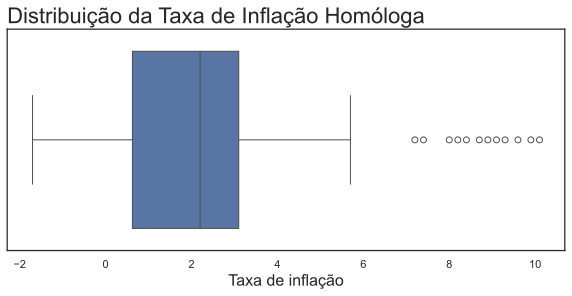

In [57]:
plt.figure(figsize=(10, 4))

sns.boxplot(df, x=target)
plt.title(
    'Distribuição da Taxa de Inflação Homóloga',
    loc='left',
    fontdict=dict(fontsize=22)
)
plt.xlabel(
    'Taxa de inflação',
    fontdict=dict(fontsize=16)
)

plt.savefig('Imagens/Boxplot Alvo.png', dpi=600 , bbox_inches='tight')

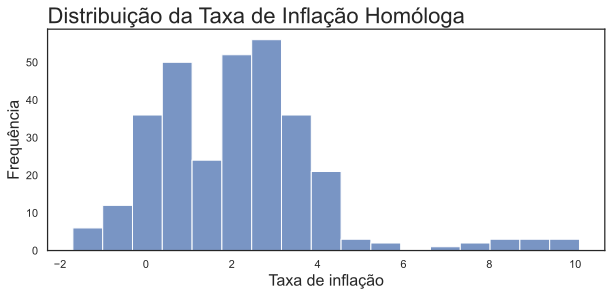

In [58]:
plt.figure(figsize=(10, 4))

sns.histplot(df, x=target)
plt.title(
    'Distribuição da Taxa de Inflação Homóloga',
    loc='left',
    fontdict=dict(fontsize=22)
)

plt.xlabel(
    'Taxa de inflação',
    fontdict=dict(fontsize=16)
)
plt.ylabel(
    'Frequência',
    fontdict=dict(fontsize=16)
)

plt.savefig('Imagens/Histograma Alvo.png', dpi=500, bbox_inches='tight')

In [59]:
round(df[[target]].describe(), 2)

,inflation_target
count,310.00
mean,2.15
std,1.97
min,-1.70
25%,0.62
50%,2.20
75%,3.10
max,10.10


In [60]:
extra_cols = df.drop(fred_var + ea_md_var + ea_qd_var + ['Date', 'month', 'year', 'exchange_exchange'], axis=1).columns

In [61]:
extra_cols

Index(['epu_pt_epu', 'unemployment_up_15_unemployment', 'PPIPT_ppi',
       'inflation_target'],
      dtype='object')

In [62]:
from statsmodels.tsa.stattools import kpss
from pmdarima.arima.utils import ndiffs

for col in extra_cols:
    # aplicar teste
    result = kpss(df[col], regression='ct')
    
    # outputs principais
    print("=" * 40)
    print(f"Coluna: {col.split('_')[0]}")
    print("=" * 40)
    print('KPSS Statistic:', result[0])
    print('p-value:', result[1])
    print('Estacionária: ', result[1] >= 0.05)
    if not result[1] >= 0.05:
        d = ndiffs(df[col], test='kpss')
        print('   Diferenciações necessárias: ', d)
    print('Critical Values:', result[3])
print("=" * 40)

Coluna: epu
KPSS Statistic: 0.12047337712117123
p-value: 0.09727152384968289
Estacionária:  True
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


C:\Users\josev\AppData\Local\Temp\ipykernel_53260\839284195.py:6: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




Coluna: unemployment
KPSS Statistic: 0.5608848637120445
p-value: 0.01
Estacionária:  False
   Diferenciações necessárias:  2
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


C:\Users\josev\AppData\Local\Temp\ipykernel_53260\839284195.py:6: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Coluna: PPIPT
KPSS Statistic: 0.11129447918302347
p-value: 0.1
Estacionária:  True
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


C:\Users\josev\AppData\Local\Temp\ipykernel_53260\839284195.py:6: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




Coluna: inflation
KPSS Statistic: 0.24231913173848252
p-value: 0.01
Estacionária:  False
   Diferenciações necessárias:  1
Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


---
# Train & Test Split
---

In [63]:
train = df.loc[df['Date'] <= "2023-06-01"].copy()
test = df.loc[df['Date'] > "2022-06-01"].copy()

In [64]:
print(' ' * 9, "Resumo dos datasets")
datasets = {
    'train': train,
    'test': test
}

for name, data in datasets.items():
    print("=" * 40)
    print(f"{name.capitalize():^40}")
    print(f"Observações: {data.shape[0]} - {((100 * data.shape[0]) / df.shape[0]):.0f}%")
    print(f"Colunas: {data.shape[1]}")
    print(f"De: {data.Date.min()}")
    print(f"Até: {data.Date.max()}")
print("=" * 40)

          Resumo dos datasets
                 Train                  
Observações: 282 - 91%
Colunas: 123
De: 2000-01-01 00:00:00
Até: 2023-06-01 00:00:00
                  Test                  
Observações: 40 - 13%
Colunas: 123
De: 2022-07-01 00:00:00
Até: 2025-10-01 00:00:00


In [65]:
cols_to_drop = [c for c in ["month", "year"] if c in train.columns]
for name, data in datasets.items():
    data.drop(columns=cols_to_drop, errors="ignore").to_csv(f'dados/{name}.csv', index=False)